In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import plotly.graph_objects as go
from trend_analisys_rsi_markov import TrendAnalyzer
import warnings
from scripts.assetsRoster import carteira_AC, carteira_HB, others
warnings.filterwarnings('ignore')


In [2]:
asset_ids = [
    'bitcoin', 'ethereum', 'binancecoin', 'ripple', 'cardano',
    'solana', 'polkadot', 'avalanche-2', 'chainlink', 'uniswap',
    'heyanon'
]

In [3]:
data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/'
btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv'
ssr_data_path='/Users/valter.rebelo/MissionControl/data/onchainData/BTC_SSR.csv'

In [4]:
analyzer = TrendAnalyzer(
    asset_ids=carteira_AC,
    data_path=data_path,
    btc_data_path=btc_data_path,
    ssr_data_path=ssr_data_path,
    use_btc_adjusted=True,
    verbose=True,
    lookback_days=180,
    trend_metrics_lookback=365,
    markov_model_name='20250325_144631'
)

2025-03-25 19:27:56,808 - INFO - Loaded Markov volatility model: 20250325_144631
2025-03-25 19:27:56,811 - INFO - Successfully loaded SSR data with 2347 rows.


Data loaded successfully: 4101 records
Training set: 3280 records
Test set: 821 records
Model metadata:
  Saved on: 2025-03-25
  Data range: 2014-01-01 to 2025-03-24
  Records: 4101 total, 3075 train, 1026 test
Model loaded from /Users/valter.rebelo/MissionControl/models/markov_volatility_model_20250325_144631.pkl


In [ ]:
btc_data = analyzer.asset_data.get('bitcoin').get('classified_data')
# Create a copy of the full date range
all_dates = btc_data[btc_data['date'] >= '2019-01-01'].copy()
# Create a mask for the condition
condition_mask = (#((all_dates['Short Term (BTC)'] == 'Strong Bull') | (all_dates['Short Term (BTC)'] == 'Weak Bull')) 
                 
#                 &

                 ((all_dates['Overall (USD)'] == 'Strong Bull') | (all_dates['Overall (USD)'] == 'Weak Bull'))
                 
                 &

                 ((all_dates['Short Term (USD)'] == 'Strong Bull')))

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create the plotly figure
fig = go.Figure()

# Add a base line trace with the complete price history (in red by default)
fig.add_trace(go.Scatter(
    x=all_dates['date'],
    y=all_dates['close'],
    mode='lines',
    name='Non-matching conditions',
    line=dict(color='red', width=2)
))

# Add green trace only for the matching conditions
# Create a copy with NaN values for non-matching points
matching_data = all_dates.copy()
matching_data.loc[~condition_mask, 'close'] = np.nan

fig.add_trace(go.Scatter(
    x=matching_data['date'],
    y=matching_data['close'],
    mode='lines',
    name='Matching conditions',
    line=dict(color='green', width=2),
    connectgaps=False
))

# Update layout
fig.update_layout(
    title='Classificação de Tendência: BTC',
    xaxis_title='Date',
    yaxis_title='Close Price (USD)',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'
)

# Add grid
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

# Show the plot
fig.show()

# Make sure every date is classified in one of the two categories
total_points = len(all_dates)
matching_points = condition_mask.sum()
non_matching_points = (~condition_mask).sum()

# Verify that all points are classified
if matching_points + non_matching_points != total_points:
    print(f"Warning: {total_points - (matching_points + non_matching_points)} points were not classified")

In [ ]:
btc_data = analyzer.asset_data.get('ripple').get('classified_data')
# Create a copy of the full date range
all_dates = btc_data[btc_data['date'] >= '2019-01-01'].copy()
# Create a mask for the condition
condition_mask = (((all_dates['Short Term (BTC)'] == 'Strong Bull') | (all_dates['Short Term (BTC)'] == 'Weak Bull')) 
                 
#                 &

                # ((all_dates['Overall (BTC)'] == 'Strong Bull'))
                 
                 &

                 ((all_dates['Short Term (USD)'] == 'Strong Bull')))    

import numpy as np
import plotly.graph_objects as go

# Create two separate dataframes for plotting
matching_data = all_dates.copy()
non_matching_data = all_dates.copy()

# For matching conditions: keep only matching points, set others to NaN
matching_data.loc[~condition_mask, 'close'] = np.nan

# For non-matching conditions: keep only non-matching points, set others to NaN
non_matching_data.loc[condition_mask, 'close'] = np.nan

# Create plotly figure
fig = go.Figure()

# Add traces for matching and non-matching conditions
fig.add_trace(go.Scatter(
    x=matching_data['date'],
    y=matching_data['close'],
    mode='lines',
    name='Matching conditions',
    line=dict(color='green', width=2),
    connectgaps=False
))

fig.add_trace(go.Scatter(
    x=non_matching_data['date'],
    y=non_matching_data['close'],
    mode='lines',
    name='Non-matching conditions',
    line=dict(color='red', width=2),
    connectgaps=False
))

# Update layout
fig.update_layout(
    title='Classificação de Tendência: XRP',
    xaxis_title='Date',
    yaxis_title='Close Price (USD)',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'
)

# Add grid
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

# Show the plot
fig.show()

# Make sure every date is classified in one of the two categories
total_points = len(all_dates)
matching_points = matching_data['close'].notna().sum()
non_matching_points = non_matching_data['close'].notna().sum()

# Verify that all points are classified
if matching_points + non_matching_points != total_points:
    print(f"Warning: {total_points - (matching_points + non_matching_points)} points were not classified")

In [5]:

# Analyze assets
analyzer.analyze_multiple_assets()


Analyzing assets (static):   0%|          | 0/16 [00:00<?, ?it/s]2025-03-25 19:27:57,024 - INFO - Successfully loaded data for bitcoin with 4349 rows.


Computing lookback metrics: 100%|██████████| 16/16 [00:00<00:00, 29.42it/s]
2025-03-25 19:28:39,025 - INFO - Trend analysis completed for multiple assets.


,Ticker,Short Term Trend (USD),Medium Term Trend (USD),Long Term Trend (USD),Overall Trend (USD),Short Term Trend (BTC),Medium Term Trend (BTC),Long Term Trend (BTC),Overall Trend (BTC),Sharpe Ratio (USD),...,Current Trend Sortino (USD),Current Trend Mean Return (USD),Current Trend Median Return (USD),Current Trend Skew (USD),Current Trend Sharpe (BTC),Current Trend Sortino (BTC),Current Trend Mean Return (BTC),Current Trend Median Return (BTC),Current Trend Skew (BTC),Latest Date
0,BTC,Strong Bull,Weak Bear,Weak Bull,Weak Bull,None,None,None,None,1.109697,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
1,ETH,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Strong Bull,Strong Bear,Strong Bear,Weak Bear,1.178833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
2,SOL,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Strong Bull,Strong Bear,Strong Bear,Weak Bear,1.418917,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
3,MKR,Strong Bull,Weak Bull,Strong Bear,Weak Bull,Weak Bear,Weak Bull,Strong Bear,Weak Bear,0.582711,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
4,LINK,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Strong Bull,Strong Bear,Strong Bear,Weak Bear,1.065401,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
5,RUNE,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Weak Bull,Weak Bear,Strong Bear,Weak Bear,1.208192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
6,STX,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Strong Bull,Strong Bear,Strong Bear,Weak Bear,0.747539,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
7,IMX,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Strong Bull,Strong Bear,Strong Bear,Weak Bear,0.089044,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
8,UNI,Strong Bull,Strong Bear,Strong Bear,Weak Bear,Strong Bull,Strong Bear,Strong Bear,Weak Bear,0.700496,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24
9,PENDLE,Strong Bull,Weak Bull,Strong Bear,Weak Bull,Strong Bull,Weak Bull,Strong Bear,Weak Bull,0.838775,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-03-24


In [28]:
start_date='2023-12-31'
end_date='2025-03-23'

analyzer.create_portfolio(
    portfolio_name='btc_gated_rsi_vol_momentum',
    #btc_trend_gating={'Overall (USD)': ['Strong Bull'], 'Short Term (USD)': ['Strong Bull']},
    btc_conditions={'Short Term (BTC)': ['Strong Bull'], 'Overall (BTC)': ['Strong Bull']},
    usd_conditions={'Overall (USD)': ['Strong Bull']},
    rsi_conditions_usd=True,  # Require RSI vs USD to be 1
    rsi_conditions_btc=True,
    use_ssr_gate=True,
    use_volatility_filter=True,
    volatility_weight=1   # Require RSI vs BTC to be 1 for altcoins
)

# Create a BTC-only trend-following portfolio
analyzer.create_portfolio(
    portfolio_name='btc_trend_following',
   # usd_conditions={'Short Term (USD)': ['Weak Bull','Strong Bull']},
    btc_only=True,
    btc_trend_gating=None,
    rsi_conditions_usd=True,
    use_ssr_signal=True,
    use_volatility_filter=True,
    volatility_weight=1
)

# Backtest the altcoin portfolio
results_alt = analyzer.backtest_portfolio(
    portfolio_name='btc_gated_rsi_vol_momentum',
    start_date=start_date,
    end_date=end_date,
    initial_capital=10000,
    alt_cost=0.005
)

# Backtest the BTC trend-following portfolio
results_btc = analyzer.backtest_portfolio(
    portfolio_name='btc_trend_following',
    start_date=start_date,
    end_date=end_date,
    initial_capital=10000,
    alt_cost=0.001,
)

2025-03-25 19:34:40,698 - WARNING - Portfolio btc_gated_rsi_vol_momentum already exists. Overwriting.
2025-03-25 19:34:40,700 - INFO - Portfolio 'btc_gated_rsi_vol_momentum' created with criteria: BTC gating=None, USD conditions={'Overall (USD)': ['Strong Bull']}, BTC conditions={'Short Term (BTC)': ['Strong Bull'], 'Overall (BTC)': ['Strong Bull']}, RSI USD=True, RSI BTC=True, volatility filter=True, volatility weight=1, SSR signal=False, SSR gate=True, BTC only=False
2025-03-25 19:34:40,701 - WARNING - Portfolio btc_trend_following already exists. Overwriting.
2025-03-25 19:34:40,701 - INFO - Portfolio 'btc_trend_following' created with criteria: BTC gating=None, USD conditions=None, BTC conditions=None, RSI USD=True, RSI BTC=False, volatility filter=True, volatility weight=1, SSR signal=True, SSR gate=False, BTC only=True
2025-03-25 19:34:43,339 - INFO - Backtest completed: Return=229.02%, Max DD=-54.78%
2025-03-25 19:34:43,354 - INFO - Entering BTC position on 2024-01-08 00:00:00: 

In [29]:


# Plot performance for a specific date range
fig = analyzer.plot_portfolio_performance(
    portfolio_names=['btc_gated_rsi_vol_momentum'],
    btc_trend_portfolio_name='btc_trend_following',
    start_date=start_date,
    end_date=end_date,
    initial_capital=10000,
    show_plot=True
)


2025-03-25 19:34:43,668 - INFO - Recalculating backtest for portfolio 'btc_gated_rsi_vol_momentum' from 2023-12-31 to 2025-03-23.
2025-03-25 19:34:46,331 - INFO - Backtest completed: Return=229.02%, Max DD=-54.78%
2025-03-25 19:34:46,332 - INFO - Recalculating backtest for portfolio 'btc_trend_following' from 2023-12-31 to 2025-03-23.
2025-03-25 19:34:46,348 - INFO - Entering BTC position on 2024-01-08 00:00:00: Cost = 10.00
2025-03-25 19:34:46,349 - INFO - Exiting BTC position on 2024-01-09 00:00:00: Cost = 9.99
2025-03-25 19:34:46,351 - INFO - Entering BTC position on 2024-01-10 00:00:00: Cost = 9.98
2025-03-25 19:34:46,353 - INFO - Exiting BTC position on 2024-01-13 00:00:00: Cost = 9.29
2025-03-25 19:34:46,354 - INFO - Entering BTC position on 2024-01-14 00:00:00: Cost = 9.28
2025-03-25 19:34:46,356 - INFO - Exiting BTC position on 2024-01-16 00:00:00: Cost = 9.24
2025-03-25 19:34:46,366 - INFO - Entering BTC position on 2024-01-30 00:00:00: Cost = 9.23
2025-03-25 19:34:46,387 - IN


Performance Metrics:
BTC Buy & Hold: Return = 103.25%, Max Drawdown = -26.23%
BTC Trend (btc_trend_following): Return = 95.06%, Max Drawdown = -19.76%

Portfolio 'btc_gated_rsi_vol_momentum':
Total Return: 229.02%
Max Drawdown: -54.78%
Total Transaction Costs: 17780.57
Sharpe Ratio: 1.61
Sortino Ratio: 1.91


In [30]:
data = '2024-04-3'

signals = results_btc['signals_df']

signals[signals.index == data]

,asset,trend_signal,rsi_usd_signal,rsi_btc_signal,volatility_signal,ssr_signal,ssr_gate,btc_gate,combined_signal,final_decision
date,,,,,,,,,,
2024-04-03,BTC,None,-1,None,1,-1,None,None,-1,0


In [31]:
btc_data = analyzer.asset_data['bitcoin'].get('classified_data')[['date', 'Short Term (USD)', 'Overall (USD)', 'RSI_Signal_close']]
btc_data[btc_data['date'] == data]


,date,Short Term (USD),Overall (USD),RSI_Signal_close
3995,2024-04-03,Weak Bull,Strong Bull,-1


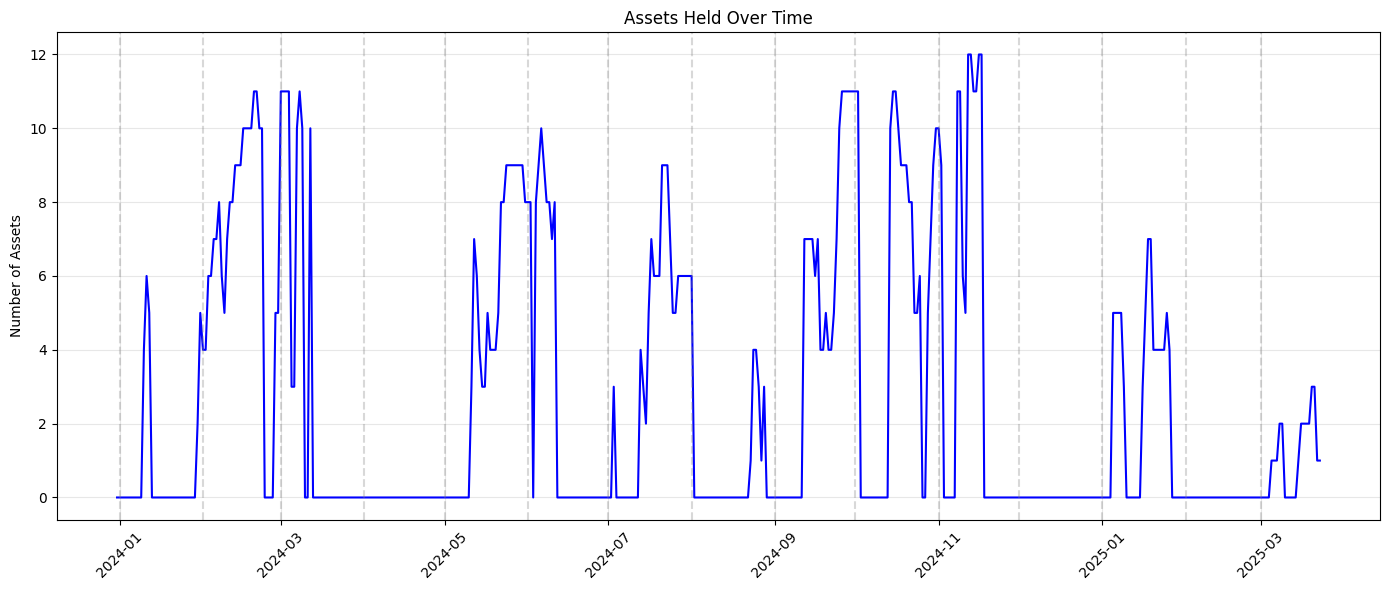

In [39]:
import matplotlib.pyplot as plt

# Get the results dataframe
results_df = analyzer.get_portfolio_details(portfolio_name='btc_gated_rsi_vol_momentum').get('backtest_results').get('results_df')

# Create the plot
plt.figure(figsize=(14, 6))

# Plot the assets held line
plt.plot(results_df.index, results_df['Assets_Held'], 'b-')

# Add vertical lines for each month
for date in results_df.index[results_df.index.is_month_start]:
    plt.axvline(x=date, color='gray', alpha=0.3, linestyle='--')

plt.title('Assets Held Over Time')
plt.ylabel('Number of Assets')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

In [45]:
analyzer.asset_data.get('bitcoin')

{'raw_data':            date      open      high       low     close
 2    2013-04-28    135.30    135.30    135.30    135.30
 3    2013-04-29    141.96    141.96    141.96    141.96
 4    2013-04-30    135.30    135.30    135.30    135.30
 5    2013-05-01    117.00    117.00    117.00    117.00
 6    2013-05-02    103.43    103.43    103.43    103.43
 ...         ...       ...       ...       ...       ...
 4346 2025-03-20  87394.00  87431.00  83736.00  84271.00
 4347 2025-03-21  84326.00  84770.00  83239.00  84010.00
 4348 2025-03-22  84046.00  84492.00  83709.00  83793.00
 4349 2025-03-23  83823.00  85826.00  83823.00  85788.00
 4350 2025-03-24  86114.00  88714.00  85560.00  87328.00
 
 [4349 rows x 5 columns],
 'classified_data':            date      open      high       low     close  returns_usd  \
 2    2013-04-28    135.30    135.30    135.30    135.30          NaN   
 3    2013-04-29    141.96    141.96    141.96    141.96     0.049224   
 4    2013-04-30    135.30    135.30  